In [113]:
from sklearn.metrics import roc_curve, auc
from sklearn import datasets
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import LinearSVC
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd
from scipy.stats.distributions import chi2
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
#import seaborn as sns
import sys
sys.path.append('..')
np.set_printoptions(suppress=True)

In [114]:
plt.style.use('ggplot')
#plt.rcParams['axes.facecolor']='w'

In [115]:
def likelihood_ratio(lik_reduced, lik_full):
    return(-np.asarray(lik_full)-(-np.asarray(lik_reduced)))

In [116]:
data = pd.read_csv('df_dynamics.csv')

In [117]:
data2 = pd.read_csv('df_flat.csv')

In [118]:
data2['model'] = 1000 # noise model

In [119]:
data = pd.concat([data, data2])

In [120]:
loglik_results = pd.read_csv('output/loglik_results_simulated_data.csv')
#loglik_results = pd.read_csv('output/loglik_results_simulated_data_noise_sd_01.csv')
loglik_results2 = pd.read_csv('output/loglik_results_simulated_data_flat.csv')

In [121]:
loglik_results = pd.concat([loglik_results, loglik_results2])

In [122]:
loglik_results['model'] = data['model']

In [123]:
#model2 = loglik_results[loglik_results['p_val_21']<0.15]

In [124]:
loglik_results['inferred_label_2'] = 0
loglik_results['true_label_2'] = 0

loglik_results['inferred_label_3'] = 0
loglik_results['true_label_3'] = 0

loglik_results['inferred_label_4'] = 0
loglik_results['true_label_4'] = 0

loglik_results['inferred_label_5'] = 0
loglik_results['true_label_5'] = 0

loglik_results['inferred_label_6'] = 0
loglik_results['true_label_6'] = 0

loglik_results['inferred_label_7'] = 0
loglik_results['true_label_7'] = 0

loglik_results['inferred_label_8'] = 0
loglik_results['true_label_8'] = 0

loglik_results['inferred_label_9'] = 0
loglik_results['true_label_9'] = 0

loglik_results['inferred_label_10'] = 0
loglik_results['true_label_10'] = 0

loglik_results['inferred_label_11'] = 0
loglik_results['true_label_11'] = 0

In [125]:
# Do we need to compute p_val_81?

In [126]:
threshold = 0.15

In [127]:
for i in range(0,2200):
    if(loglik_results.iloc[i]['p_val_21']<threshold and loglik_results.iloc[i]['p_val_31']>threshold and 
       loglik_results.iloc[i]['p_val_82']>threshold and loglik_results.iloc[i]['p_val_42']>threshold and 
       loglik_results.iloc[i]['p_val_43']>threshold):
        loglik_results['inferred_label_2'].iloc[i] = 1
    if(loglik_results.iloc[i]['model']==2):  
        loglik_results['true_label_2'].iloc[i] = 1   

/var/folders/pn/vpqz4z_53xl4fpq_28c5mx700000gn/T/ipykernel_24748/3392119199.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loglik_results['inferred_label_2'].iloc[i] = 1
/var/folders/pn/vpqz4z_53xl4fpq_28c5mx700000gn/T/ipykernel_24748/3392119199.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loglik_results['true_label_2'].iloc[i] = 1


In [128]:
#loglik_results = loglik_results[loglik_results['model'].isin([1,2])]

In [129]:
#loglik_results[loglik_results['model']==2]['p_val_82']

In [130]:
# # Compute ROC curve and ROC area for each class
# #fpr = dict()
# #tpr = dict()
# #roc_auc = dict()
# #for i in range(n_classes):
# fpr, tpr, _ = roc_curve(loglik_results['inferred_label_2'].to_numpy(), loglik_results['true_label_2'].to_numpy())
# roc_auc = auc(fpr, tpr)

In [131]:
# plt.figure()
# plt.plot(fpr, tpr, '--', label='ROC curve (area = %0.2f)' % roc_auc)
# plt.plot([0, 1], [0, 1], 'k--')
# plt.xlim([0.0, 1.0])
# plt.ylim([0.0, 1.05])
# plt.xlabel('False Positive Rate')
# plt.ylabel('True Positive Rate')
# plt.title('Receiver operating characteristic example')
# plt.legend(loc="lower right")
# plt.show()

In [132]:
#sum(loglik_results['true_label'])

### Model 3

In [133]:
loglik_results['p_val_11_3'] = chi2.sf(likelihood_ratio(loglik_results['model_8'], loglik_results['model_11']), 2) #???

In [134]:
loglik_results['p_val_9_11'] = chi2.sf(likelihood_ratio(loglik_results['model_11'], loglik_results['model_9']), 2) #???

In [135]:
loglik_results['p_val_10_5'] = chi2.sf(likelihood_ratio(loglik_results['model_5'], loglik_results['model_10']), 2) #???

In [136]:
loglik_results['p_val_11_4'] = chi2.sf(likelihood_ratio(loglik_results['model_4'], loglik_results['model_11']), 2) #???

In [137]:
for i in range(0,2200):
    #if(loglik_results.iloc[i]['p_val_31']<threshold and loglik_results.iloc[i]['p_val_21']>threshold and 
    #   loglik_results.iloc[i]['p_val_53']>threshold and loglik_results.iloc[i]['p_val_43']>threshold and 
    #   loglik_results.iloc[i]['p_val_42']>threshold):
    if(loglik_results.iloc[i]['p_val_31']<threshold and loglik_results.iloc[i]['p_val_21']>threshold and 
      loglik_results.iloc[i]['p_val_63']>threshold and loglik_results.iloc[i]['p_val_9_11']>threshold and 
      loglik_results.iloc[i]['p_val_43']>threshold and loglik_results.iloc[i]['p_val_10_5']>threshold and 
      loglik_results.iloc[i]['p_val_11_4']>threshold):
        loglik_results['inferred_label_3'].iloc[i] = 1
    if(loglik_results.iloc[i]['model']==3):  
        loglik_results['true_label_3'].iloc[i] = 1   

/var/folders/pn/vpqz4z_53xl4fpq_28c5mx700000gn/T/ipykernel_24748/3782403986.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loglik_results['inferred_label_3'].iloc[i] = 1
/var/folders/pn/vpqz4z_53xl4fpq_28c5mx700000gn/T/ipykernel_24748/3782403986.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loglik_results['true_label_3'].iloc[i] = 1


In [138]:
#loglik_results[loglik_results['model']==1]

In [139]:
# # Compute ROC curve and ROC area for each class
# #fpr = dict()
# #tpr = dict()
# #roc_auc = dict()
# #for i in range(n_classes):
# fpr, tpr, _ = roc_curve(loglik_results['inferred_label'].to_numpy(), loglik_results['true_label'].to_numpy())
# roc_auc = auc(fpr, tpr)

In [140]:
# plt.figure()
# plt.plot(fpr, tpr, '--', label='ROC curve (area = %0.2f)' % roc_auc)
# plt.plot([0, 1], [0, 1], 'k--')
# plt.xlim([0.0, 1.0])
# plt.ylim([0.0, 1.05])
# plt.xlabel('False Positive Rate')
# plt.ylabel('True Positive Rate')
# plt.title('Receiver operating characteristic example')
# plt.legend(loc="lower right")
# plt.show()

In [141]:
#sum(loglik_results['true_label']-loglik_results['inferred_label'])

In [142]:
#np.unique(loglik_results[loglik_results['inferred_label']==1]['model'])

### Model 4

In [143]:
loglik_results['p_val_43'] = chi2.sf(likelihood_ratio(loglik_results['model_3'], loglik_results['model_4']), 2) #???

In [144]:
loglik_results['p_val_10_4'] = chi2.sf(likelihood_ratio(loglik_results['model_4'], loglik_results['model_10']), 2) #???

In [145]:
loglik_results['p_val_9_10'] = chi2.sf(likelihood_ratio(loglik_results['model_10'], loglik_results['model_9']), 2) #???

In [146]:
# loglik_results['inferred_label'] = 0
# loglik_results['true_label'] = 0

In [147]:
for i in range(0,2200):
    #if(loglik_results.iloc[i]['p_val_31']<threshold and loglik_results.iloc[i]['p_val_21']>threshold and 
    #   loglik_results.iloc[i]['p_val_53']>threshold and loglik_results.iloc[i]['p_val_43']>threshold and 
    #   loglik_results.iloc[i]['p_val_42']>threshold):
    if(loglik_results.iloc[i]['p_val_43']<threshold and loglik_results.iloc[i]['p_val_42']<threshold and 
       loglik_results.iloc[i]['p_val_11_4']>threshold and loglik_results.iloc[i]['p_val_10_4']>threshold and 
       loglik_results.iloc[i]['p_val_9_11']>threshold and loglik_results.iloc[i]['p_val_9_10']>threshold and
       loglik_results.iloc[i]['p_val_53']>threshold and loglik_results.iloc[i]['p_val_82']>threshold):
        loglik_results['inferred_label_4'].iloc[i] = 1
    if(loglik_results.iloc[i]['model']==4):  
        loglik_results['true_label_4'].iloc[i] = 1   

/var/folders/pn/vpqz4z_53xl4fpq_28c5mx700000gn/T/ipykernel_24748/1396202605.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loglik_results['inferred_label_4'].iloc[i] = 1
/var/folders/pn/vpqz4z_53xl4fpq_28c5mx700000gn/T/ipykernel_24748/1396202605.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loglik_results['true_label_4'].iloc[i] = 1


In [148]:
#loglik_results[loglik_results['model']==4]

In [149]:
# # Compute ROC curve and ROC area for each class
# #fpr = dict()
# #tpr = dict()
# #roc_auc = dict()
# #for i in range(n_classes):
# fpr, tpr, _ = roc_curve(loglik_results['inferred_label'].to_numpy(), loglik_results['true_label'].to_numpy())
# roc_auc = auc(fpr, tpr)

In [150]:
# plt.figure()
# plt.plot(fpr, tpr, '--', label='ROC curve (area = %0.2f)' % roc_auc)
# plt.plot([0, 1], [0, 1], 'k--')
# plt.xlim([0.0, 1.0])
# plt.ylim([0.0, 1.05])
# plt.xlabel('False Positive Rate')
# plt.ylabel('True Positive Rate')
# plt.title('Receiver operating characteristic example')
# plt.legend(loc="lower right")
# plt.show()

In [151]:
# sum(loglik_results['true_label']-loglik_results['inferred_label'])

In [152]:
# np.unique(loglik_results[loglik_results['inferred_label']==1]['model'])

In [153]:
# test = loglik_results[loglik_results['inferred_label']==1]
# test[test['model']==3]

### Model 5

In [154]:
loglik_results['p_val_56'] = chi2.sf(likelihood_ratio(loglik_results['model_6'], loglik_results['model_5']), 2) #???

In [155]:
# loglik_results['inferred_label'] = 0
# loglik_results['true_label'] = 0

In [156]:
for i in range(0,2200):
    #if(loglik_results.iloc[i]['p_val_31']<threshold and loglik_results.iloc[i]['p_val_21']>threshold and 
    #   loglik_results.iloc[i]['p_val_53']>threshold and loglik_results.iloc[i]['p_val_43']>threshold and 
    #   loglik_results.iloc[i]['p_val_42']>threshold):
    if(loglik_results.iloc[i]['p_val_53']<threshold and loglik_results.iloc[i]['p_val_56']<threshold):
        loglik_results['inferred_label_5'].iloc[i] = 1
    if(loglik_results.iloc[i]['model']==5):  
        loglik_results['true_label_5'].iloc[i] = 1   

/var/folders/pn/vpqz4z_53xl4fpq_28c5mx700000gn/T/ipykernel_24748/3884813799.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loglik_results['inferred_label_5'].iloc[i] = 1
/var/folders/pn/vpqz4z_53xl4fpq_28c5mx700000gn/T/ipykernel_24748/3884813799.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loglik_results['true_label_5'].iloc[i] = 1


In [157]:
#loglik_results[loglik_results['model']==5]

In [158]:
# # Compute ROC curve and ROC area for each class
# #fpr = dict()
# #tpr = dict()
# #roc_auc = dict()
# #for i in range(n_classes):
# fpr, tpr, _ = roc_curve(loglik_results['inferred_label'].to_numpy(), loglik_results['true_label'].to_numpy())
# roc_auc = auc(fpr, tpr)

In [159]:
# plt.figure()
# plt.plot(fpr, tpr, '--', label='ROC curve (area = %0.2f)' % roc_auc)
# plt.plot([0, 1], [0, 1], 'k--')
# plt.xlim([0.0, 1.0])
# plt.ylim([0.0, 1.05])
# plt.xlabel('False Positive Rate')
# plt.ylabel('True Positive Rate')
# plt.title('Receiver operating characteristic example')
# plt.legend(loc="lower right")
# plt.show()

In [160]:
# sum(loglik_results['true_label']-loglik_results['inferred_label'])

In [161]:
# np.unique(loglik_results[loglik_results['inferred_label']==1]['model'])

In [162]:
# test = loglik_results[loglik_results['inferred_label']==1]
# test[test['model']==5]

### Model 6

In [163]:
loglik_results['p_val_96'] = chi2.sf(likelihood_ratio(loglik_results['model_6'], loglik_results['model_9']), 2) #???

In [164]:
for i in range(0,2200):
    #if(loglik_results.iloc[i]['p_val_31']<threshold and loglik_results.iloc[i]['p_val_21']>threshold and 
    #   loglik_results.iloc[i]['p_val_53']>threshold and loglik_results.iloc[i]['p_val_43']>threshold and 
    #   loglik_results.iloc[i]['p_val_42']>threshold):
    if(loglik_results.iloc[i]['p_val_61']<threshold and loglik_results.iloc[i]['p_val_63']<threshold and 
       loglik_results.iloc[i]['p_val_56']>threshold and 
       loglik_results.iloc[i]['p_val_21']>threshold and loglik_results.iloc[i]['p_val_96']>threshold):
        # loglik_results.iloc[i]['p_val_63']<threshold and
        loglik_results['inferred_label_6'].iloc[i] = 1
    if(loglik_results.iloc[i]['model']==6):  
        loglik_results['true_label_6'].iloc[i] = 1   

/var/folders/pn/vpqz4z_53xl4fpq_28c5mx700000gn/T/ipykernel_24748/3568077552.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loglik_results['inferred_label_6'].iloc[i] = 1
/var/folders/pn/vpqz4z_53xl4fpq_28c5mx700000gn/T/ipykernel_24748/3568077552.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loglik_results['true_label_6'].iloc[i] = 1


In [165]:
# # Compute ROC curve and ROC area for each class
# #fpr = dict()
# #tpr = dict()
# #roc_auc = dict()
# #for i in range(n_classes):
# fpr, tpr, _ = roc_curve(loglik_results['inferred_label'].to_numpy(), loglik_results['true_label'].to_numpy())
# roc_auc = auc(fpr, tpr)

In [166]:
# plt.figure()
# plt.plot(fpr, tpr, '--', label='ROC curve (area = %0.2f)' % roc_auc)
# plt.plot([0, 1], [0, 1], 'k--')
# plt.xlim([0.0, 1.0])
# plt.ylim([0.0, 1.05])
# plt.xlabel('False Positive Rate')
# plt.ylabel('True Positive Rate')
# plt.title('Receiver operating characteristic example')
# plt.legend(loc="lower right")
# plt.show()

In [167]:
# sum(loglik_results['true_label']-loglik_results['inferred_label'])

In [168]:
# np.unique(loglik_results[loglik_results['inferred_label']==1]['model'])

In [169]:
# test = loglik_results[loglik_results['inferred_label']==1]
# test[test['model']==6]

In [170]:
# test = loglik_results[loglik_results['p_val_9_11']<0.15]
# test[test['model']==6]

### Model 7

In [171]:
loglik_results['p_val_72'] = chi2.sf(likelihood_ratio(loglik_results['model_2'], loglik_results['model_7']), 2) #???

In [172]:
loglik_results['p_val_87'] = chi2.sf(likelihood_ratio(loglik_results['model_7'], loglik_results['model_8']), 2) #???

In [173]:
loglik_results['p_val_11_8'] = chi2.sf(likelihood_ratio(loglik_results['model_8'], loglik_results['model_11']), 2) #???

In [174]:
# loglik_results['inferred_label'] = 0
# loglik_results['true_label'] = 0

In [175]:
for i in range(0,2200):
    #if(loglik_results.iloc[i]['p_val_31']<threshold and loglik_results.iloc[i]['p_val_21']>threshold and 
    #   loglik_results.iloc[i]['p_val_53']>threshold and loglik_results.iloc[i]['p_val_43']>threshold and 
    #   loglik_results.iloc[i]['p_val_42']>threshold):
    if(loglik_results.iloc[i]['p_val_71']<threshold and loglik_results.iloc[i]['p_val_72']<threshold and 
       loglik_results.iloc[i]['p_val_87']>threshold and 
       loglik_results.iloc[i]['p_val_31']>threshold and loglik_results.iloc[i]['p_val_11_8']>threshold):
        # loglik_results.iloc[i]['p_val_63']<threshold and
        loglik_results['inferred_label_7'].iloc[i] = 1
    if(loglik_results.iloc[i]['model']==7):  
        loglik_results['true_label_7'].iloc[i] = 1   

/var/folders/pn/vpqz4z_53xl4fpq_28c5mx700000gn/T/ipykernel_24748/3557923384.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loglik_results['inferred_label_7'].iloc[i] = 1
/var/folders/pn/vpqz4z_53xl4fpq_28c5mx700000gn/T/ipykernel_24748/3557923384.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loglik_results['true_label_7'].iloc[i] = 1


In [176]:
# # Compute ROC curve and ROC area for each class
# #fpr = dict()
# #tpr = dict()
# #roc_auc = dict()
# #for i in range(n_classes):
# fpr, tpr, _ = roc_curve(loglik_results['inferred_label'].to_numpy(), loglik_results['true_label'].to_numpy())
# roc_auc = auc(fpr, tpr)

In [177]:
# plt.figure()
# plt.plot(fpr, tpr, '--', label='ROC curve (area = %0.2f)' % roc_auc)
# plt.plot([0, 1], [0, 1], 'k--')
# plt.xlim([0.0, 1.0])
# plt.ylim([0.0, 1.05])
# plt.xlabel('False Positive Rate')
# plt.ylabel('True Positive Rate')
# plt.title('Receiver operating characteristic example')
# plt.legend(loc="lower right")
# plt.show()

In [178]:
# sum(loglik_results['true_label']-loglik_results['inferred_label'])

In [179]:
# np.unique(loglik_results[loglik_results['inferred_label']==1]['model'])

In [180]:
# test = loglik_results[loglik_results['inferred_label']==1]
# test[test['model']==9]

### Model 8

In [181]:
loglik_results['p_val_9_11'] = chi2.sf(likelihood_ratio(loglik_results['model_11'], loglik_results['model_9']), 2) #???

In [182]:
# loglik_results['inferred_label'] = 0
# loglik_results['true_label'] = 0

In [183]:
for i in range(0,2200):
    #if(loglik_results.iloc[i]['p_val_31']<threshold and loglik_results.iloc[i]['p_val_21']>threshold and 
    #   loglik_results.iloc[i]['p_val_53']>threshold and loglik_results.iloc[i]['p_val_43']>threshold and 
    #   loglik_results.iloc[i]['p_val_42']>threshold):
    if(loglik_results.iloc[i]['p_val_82']<threshold and loglik_results.iloc[i]['p_val_11_8']>threshold and 
      loglik_results.iloc[i]['p_val_9_11']>threshold):
        # loglik_results.iloc[i]['p_val_63']<threshold and
        loglik_results['inferred_label_8'].iloc[i] = 1
    if(loglik_results.iloc[i]['model']==8):  
        loglik_results['true_label_8'].iloc[i] = 1   

/var/folders/pn/vpqz4z_53xl4fpq_28c5mx700000gn/T/ipykernel_24748/2813945058.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loglik_results['inferred_label_8'].iloc[i] = 1
/var/folders/pn/vpqz4z_53xl4fpq_28c5mx700000gn/T/ipykernel_24748/2813945058.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loglik_results['true_label_8'].iloc[i] = 1


In [184]:
for i in range(0,2200):
    #if(loglik_results.iloc[i]['p_val_31']<threshold and loglik_results.iloc[i]['p_val_21']>threshold and 
    #   loglik_results.iloc[i]['p_val_53']>threshold and loglik_results.iloc[i]['p_val_43']>threshold and 
    #   loglik_results.iloc[i]['p_val_42']>threshold):
    if(loglik_results.iloc[i]['p_val_53']<threshold and loglik_results.iloc[i]['p_val_56']<threshold):
        loglik_results['inferred_label_5'].iloc[i] = 1
    if(loglik_results.iloc[i]['model']==5):  
        loglik_results['true_label_5'].iloc[i] = 1   

/var/folders/pn/vpqz4z_53xl4fpq_28c5mx700000gn/T/ipykernel_24748/3884813799.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loglik_results['inferred_label_5'].iloc[i] = 1
/var/folders/pn/vpqz4z_53xl4fpq_28c5mx700000gn/T/ipykernel_24748/3884813799.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loglik_results['true_label_5'].iloc[i] = 1


In [185]:
for i in range(0,2200):
    #if(loglik_results.iloc[i]['p_val_31']<threshold and loglik_results.iloc[i]['p_val_21']>threshold and 
    #   loglik_results.iloc[i]['p_val_53']>threshold and loglik_results.iloc[i]['p_val_43']>threshold and 
    #   loglik_results.iloc[i]['p_val_42']>threshold):
    if(loglik_results.iloc[i]['p_val_82']<threshold and loglik_results.iloc[i]['p_val_87']<threshold):
        # loglik_results.iloc[i]['p_val_63']<threshold and
        loglik_results['inferred_label_8'].iloc[i] = 1
    if(loglik_results.iloc[i]['model']==8):  
        loglik_results['true_label_8'].iloc[i] = 1   

/var/folders/pn/vpqz4z_53xl4fpq_28c5mx700000gn/T/ipykernel_24748/1735966754.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loglik_results['inferred_label_8'].iloc[i] = 1
/var/folders/pn/vpqz4z_53xl4fpq_28c5mx700000gn/T/ipykernel_24748/1735966754.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loglik_results['true_label_8'].iloc[i] = 1


In [186]:
# # Compute ROC curve and ROC area for each class
# #fpr = dict()
# #tpr = dict()
# #roc_auc = dict()
# #for i in range(n_classes):
# fpr, tpr, _ = roc_curve(loglik_results['inferred_label'].to_numpy(), loglik_results['true_label'].to_numpy())
# roc_auc = auc(fpr, tpr)

In [187]:
# plt.figure()
# plt.plot(fpr, tpr, '--', label='ROC curve (area = %0.2f)' % roc_auc)
# plt.plot([0, 1], [0, 1], 'k--')
# plt.xlim([0.0, 1.0])
# plt.ylim([0.0, 1.05])
# plt.xlabel('False Positive Rate')
# plt.ylabel('True Positive Rate')
# plt.title('Receiver operating characteristic example')
# plt.legend(loc="lower right")
# plt.show()

In [188]:
# sum(loglik_results['true_label']-loglik_results['inferred_label'])

In [189]:
# sum(loglik_results['inferred_label'])

In [190]:
# np.unique(loglik_results[loglik_results['inferred_label']==1]['model'])

In [191]:
# test = loglik_results[loglik_results['inferred_label']==1]
# test[test['model']==1]

### Model 9

In [192]:
loglik_results['p_val_96'] = chi2.sf(likelihood_ratio(loglik_results['model_6'], loglik_results['model_9']), 2) #???

In [193]:
# loglik_results['inferred_label'] = 0
# loglik_results['true_label'] = 0

In [194]:
for i in range(0,2200):
    #if(loglik_results.iloc[i]['p_val_31']<threshold and loglik_results.iloc[i]['p_val_21']>threshold and 
    #   loglik_results.iloc[i]['p_val_53']>threshold and loglik_results.iloc[i]['p_val_43']>threshold and 
    #   loglik_results.iloc[i]['p_val_42']>threshold):
    if(loglik_results.iloc[i]['p_val_9_11']<threshold and loglik_results.iloc[i]['p_val_9_10']<threshold and 
        loglik_results.iloc[i]['p_val_97']<threshold and loglik_results.iloc[i]['p_val_96']<threshold):
        # loglik_results.iloc[i]['p_val_63']<threshold and
        loglik_results['inferred_label_9'].iloc[i] = 1
    if(loglik_results.iloc[i]['model']==9):  
        loglik_results['true_label_9'].iloc[i] = 1   

/var/folders/pn/vpqz4z_53xl4fpq_28c5mx700000gn/T/ipykernel_24748/2339881876.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loglik_results['inferred_label_9'].iloc[i] = 1
/var/folders/pn/vpqz4z_53xl4fpq_28c5mx700000gn/T/ipykernel_24748/2339881876.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loglik_results['true_label_9'].iloc[i] = 1


In [195]:
# # Compute ROC curve and ROC area for each class
# #fpr = dict()
# #tpr = dict()
# #roc_auc = dict()
# #for i in range(n_classes):
# fpr, tpr, _ = roc_curve(loglik_results['inferred_label'].to_numpy(), loglik_results['true_label'].to_numpy())
# roc_auc = auc(fpr, tpr)

In [196]:
# plt.figure()
# plt.plot(fpr, tpr, '--', label='ROC curve (area = %0.2f)' % roc_auc)
# plt.plot([0, 1], [0, 1], 'k--')
# plt.xlim([0.0, 1.0])
# plt.ylim([0.0, 1.05])
# plt.xlabel('False Positive Rate')
# plt.ylabel('True Positive Rate')
# plt.title('Receiver operating characteristic example')
# plt.legend(loc="lower right")
# plt.show()

In [197]:
# np.unique(loglik_results[loglik_results['inferred_label']==1]['model'])

In [198]:
# sum(loglik_results['true_label']-loglik_results['inferred_label'])

In [199]:
# sum(loglik_results['inferred_label'])

### Model 10

In [200]:
loglik_results['p_val_10_5'] = chi2.sf(likelihood_ratio(loglik_results['model_5'], loglik_results['model_10']), 2) #???

In [201]:
loglik_results['p_val_10_3'] = chi2.sf(likelihood_ratio(loglik_results['model_3'], loglik_results['model_10']), 2) #???

In [202]:
loglik_results['p_val_10_1'] = chi2.sf(likelihood_ratio(loglik_results['model_1'], loglik_results['model_10']), 2) #???

In [203]:
loglik_results['p_val_10_2'] = chi2.sf(likelihood_ratio(loglik_results['model_2'], loglik_results['model_10']), 2) #???

In [204]:
loglik_results['p_val_10_4'] = chi2.sf(likelihood_ratio(loglik_results['model_4'], loglik_results['model_10']), 2) #???

In [205]:
loglik_results['p_val_11_4'] = chi2.sf(likelihood_ratio(loglik_results['model_4'], loglik_results['model_11']), 2) #???

In [206]:
# loglik_results['inferred_label'] = 0
# loglik_results['true_label'] = 0

In [207]:
for i in range(0,2200):
    #if(loglik_results.iloc[i]['p_val_31']<threshold and loglik_results.iloc[i]['p_val_21']>threshold and 
    #   loglik_results.iloc[i]['p_val_53']>threshold and loglik_results.iloc[i]['p_val_43']>threshold and 
    #   loglik_results.iloc[i]['p_val_42']>threshold):
    if(loglik_results.iloc[i]['p_val_10_4']<threshold and loglik_results.iloc[i]['p_val_10_5']<threshold and 
       loglik_results.iloc[i]['p_val_9_10']>threshold and loglik_results.iloc[i]['p_val_11_4']>threshold and
      loglik_results.iloc[i]['p_val_42']<threshold and loglik_results.iloc[i]['p_val_43']<threshold):
        # loglik_results.iloc[i]['p_val_63']<threshold and
        loglik_results['inferred_label_10'].iloc[i] = 1
    if(loglik_results.iloc[i]['model']==10):  
        loglik_results['true_label_10'].iloc[i] = 1   

/var/folders/pn/vpqz4z_53xl4fpq_28c5mx700000gn/T/ipykernel_24748/3950900615.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loglik_results['inferred_label_10'].iloc[i] = 1
/var/folders/pn/vpqz4z_53xl4fpq_28c5mx700000gn/T/ipykernel_24748/3950900615.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loglik_results['true_label_10'].iloc[i] = 1


In [208]:
# # Compute ROC curve and ROC area for each class
# #fpr = dict()
# #tpr = dict()
# #roc_auc = dict()
# #for i in range(n_classes):
# fpr, tpr, _ = roc_curve(loglik_results['inferred_label'].to_numpy(), loglik_results['true_label'].to_numpy())
# roc_auc = auc(fpr, tpr)

In [209]:
# plt.figure()
# plt.plot(fpr, tpr, '--', label='ROC curve (area = %0.2f)' % roc_auc)
# plt.plot([0, 1], [0, 1], 'k--')
# plt.xlim([0.0, 1.0])
# plt.ylim([0.0, 1.05])
# plt.xlabel('False Positive Rate')
# plt.ylabel('True Positive Rate')
# plt.title('Receiver operating characteristic example')
# plt.legend(loc="lower right")
# plt.show()

In [210]:
# np.unique(loglik_results[loglik_results['inferred_label']==1]['model'])

In [211]:
# test = loglik_results[loglik_results['inferred_label']==1]
# test[test['model']==4]

### Model 11

In [212]:
loglik_results['p_val_11_8'] = chi2.sf(likelihood_ratio(loglik_results['model_8'], loglik_results['model_11']), 2) #???

In [213]:
loglik_results['p_val_11_4'] = chi2.sf(likelihood_ratio(loglik_results['model_4'], loglik_results['model_11']), 2) #???

In [214]:
loglik_results['p_val_9_11'] = chi2.sf(likelihood_ratio(loglik_results['model_11'], loglik_results['model_9']), 2) #???

In [215]:
# loglik_results['inferred_label'] = 0
# loglik_results['true_label'] = 0

In [216]:
for i in range(0,2200):
    #if(loglik_results.iloc[i]['p_val_31']<threshold and loglik_results.iloc[i]['p_val_21']>threshold and 
    #   loglik_results.iloc[i]['p_val_53']>threshold and loglik_results.iloc[i]['p_val_43']>threshold and 
    #   loglik_results.iloc[i]['p_val_42']>threshold):
    if(loglik_results.iloc[i]['p_val_11_8']<threshold and loglik_results.iloc[i]['p_val_11_4']<threshold and 
      loglik_results.iloc[i]['p_val_9_11']>threshold and loglik_results.iloc[i]['p_val_43']<threshold):
        # loglik_results.iloc[i]['p_val_63']<threshold and
        loglik_results['inferred_label_11'].iloc[i] = 1
    if(loglik_results.iloc[i]['model']==11):  
        loglik_results['true_label_11'].iloc[i] = 1   

/var/folders/pn/vpqz4z_53xl4fpq_28c5mx700000gn/T/ipykernel_24748/814035546.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loglik_results['inferred_label_11'].iloc[i] = 1
/var/folders/pn/vpqz4z_53xl4fpq_28c5mx700000gn/T/ipykernel_24748/814035546.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loglik_results['true_label_11'].iloc[i] = 1


In [217]:
# # Compute ROC curve and ROC area for each class
# #fpr = dict()
# #tpr = dict()
# #roc_auc = dict()
# #for i in range(n_classes):
# fpr, tpr, _ = roc_curve(loglik_results['inferred_label'].to_numpy(), loglik_results['true_label'].to_numpy())
# roc_auc = auc(fpr, tpr)

In [218]:
# plt.figure()
# plt.plot(fpr, tpr, '--', label='ROC curve (area = %0.2f)' % roc_auc)
# plt.plot([0, 1], [0, 1], 'k--')
# plt.xlim([0.0, 1.0])
# plt.ylim([0.0, 1.05])
# plt.xlabel('False Positive Rate')
# plt.ylabel('True Positive Rate')
# plt.title('Receiver operating characteristic example')
# plt.legend(loc="lower right")
# plt.show()

In [219]:
# np.unique(loglik_results[loglik_results['inferred_label']==1]['model'])

In [220]:
# test = loglik_results[loglik_results['inferred_label']==1]
# test[test['model']==3]

In [221]:
fpr_2, tpr_2, _ = roc_curve(loglik_results['inferred_label_2'].to_numpy(), loglik_results['true_label_2'].to_numpy())
roc_auc_2 = auc(fpr_2, tpr_2)

fpr_3, tpr_3, _ = roc_curve(loglik_results['inferred_label_3'].to_numpy(), loglik_results['true_label_3'].to_numpy())
roc_auc_3 = auc(fpr_3, tpr_3)

fpr_4, tpr_4, _ = roc_curve(loglik_results['inferred_label_4'].to_numpy(), loglik_results['true_label_4'].to_numpy())
roc_auc_4 = auc(fpr_4, tpr_4)

fpr_5, tpr_5, _ = roc_curve(loglik_results['inferred_label_5'].to_numpy(), loglik_results['true_label_5'].to_numpy())
roc_auc_5 = auc(fpr_5, tpr_5)

fpr_6, tpr_6, _ = roc_curve(loglik_results['inferred_label_6'].to_numpy(), loglik_results['true_label_6'].to_numpy())
roc_auc_6 = auc(fpr_6, tpr_6)

fpr_7, tpr_7, _ = roc_curve(loglik_results['inferred_label_7'].to_numpy(), loglik_results['true_label_7'].to_numpy())
roc_auc_7 = auc(fpr_7, tpr_7)

fpr_8, tpr_8, _ = roc_curve(loglik_results['inferred_label_8'].to_numpy(), loglik_results['true_label_8'].to_numpy())
roc_auc_8 = auc(fpr_8, tpr_8)

fpr_9, tpr_9, _ = roc_curve(loglik_results['inferred_label_9'].to_numpy(), loglik_results['true_label_9'].to_numpy())
roc_auc_9 = auc(fpr_9, tpr_9)

fpr_10, tpr_10, _ = roc_curve(loglik_results['inferred_label_10'].to_numpy(), loglik_results['true_label_10'].to_numpy())
roc_auc_10 = auc(fpr_10, tpr_10)

fpr_11, tpr_11, _ = roc_curve(loglik_results['inferred_label_11'].to_numpy(), loglik_results['true_label_11'].to_numpy())
roc_auc_11 = auc(fpr_11, tpr_11)

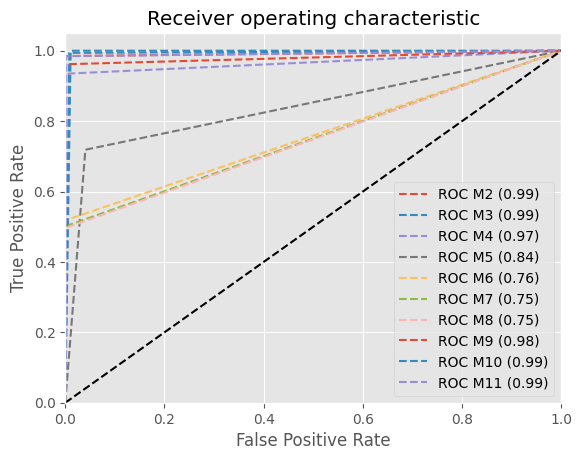

In [222]:
plt.figure()
plt.plot(fpr_2, tpr_2, '--', label='ROC M2 (%0.2f)' % roc_auc_2)
plt.plot(fpr_3, tpr_3, '--', label='ROC M3 (%0.2f)' % roc_auc_3)
plt.plot(fpr_4, tpr_4, '--', label='ROC M4 (%0.2f)' % roc_auc_4)
plt.plot(fpr_5, tpr_5, '--', label='ROC M5 (%0.2f)' % roc_auc_5)
plt.plot(fpr_6, tpr_6, '--', label='ROC M6 (%0.2f)' % roc_auc_6)
plt.plot(fpr_7, tpr_7, '--', label='ROC M7 (%0.2f)' % roc_auc_7)
plt.plot(fpr_8, tpr_8, '--', label='ROC M8 (%0.2f)' % roc_auc_8)
plt.plot(fpr_9, tpr_9, '--', label='ROC M9 (%0.2f)' % roc_auc_9)
plt.plot(fpr_10, tpr_10, '--', label='ROC M10 (%0.2f)' % roc_auc_10)
plt.plot(fpr_11, tpr_11, '--', label='ROC M11 (%0.2f)' % roc_auc_11)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")
plt.show()